# code for topic modeling of episode annotations and recall transcripts

### imports

In [48]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from collections import defaultdict
from os.path import join as opj
from hypertools.tools import format_data as transform_text
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from num2words import num2words
from scipy.signal import resample
from scipy.interpolate import interp1d

%matplotlib inline    # stops hypertools from opening subprocess

In [56]:
# try to show progress bars for long-running cells
# to properly show progress bars, you'll need to install tqdm,
# as well as widgetsnbextension and ipywidgets to render the element
try:
    from tqdm import tqdm_notebook as tqdm
    show_pbar = True
except ModuleNotFoundError:
    print('To enable progress bars, install tqdm module (`pip install tqdm`)')
    show_pbar = False

### set paths

In [2]:
data_dir = '../../data'
annot_dir = opj(data_dir, 'annotations')
transc_dir = opj(data_dir, 'transcriptions', 'manual')
ep_traj_dir = opj(data_dir, 'models', 'episodes', 'trajectories')
rec_traj_dir = opj(data_dir, 'models', 'recalls', 'trajectories')
pickle_dir = opj(data_dir, 'pickles')

### load data

In [51]:
# formatted annotations
atlep1_df = pd.read_csv(opj(annot_dir, 'atlep1.csv'))
atlep2_df = pd.read_csv(opj(annot_dir, 'atlep2.csv'))
arrdev_df = pd.read_csv(opj(annot_dir, 'arrdev.csv'))

# across-session subject IDs
id_maps = pd.read_pickle(opj(pickle_dir, 'id_maps.p'))

### topic modeling parameters

In [4]:
# text preprocessing
stop_words = stopwords.words('english')
extra_stopwords = ['like']
stop_words = stop_words.extend(extra_stopwords)

# combine some multiword phrases, subsitute expletives, etc.
substitutions = {
    # names
    'paper boy': 'paperboy',
    'earnest': 'earn',
    'vanessa': 'van',
    'george-michael': 'georgemichael',
    'flo rida': 'floxrida',
    'david': 'dave',
    # explatives
    'f-word': 'fuck',
    'n-word': 'nigga',
    'racial slur': 'nigga',
    # other words/phrases
    'low key': 'lowkey',
    'low-key': 'lowkey',
    'parking lot': 'parkinglot',
    'déja': 'deja',
    'ex girlfriend': 'exgirlfriend',
    'ex-girlfriend': 'exgirlfriend',
    'ex wife': 'exwife',
    'ex-wife': 'exwife',
    # surround potential sub-words with spaces
    ' cause ': ' because ',
    ' weed ': ' marijuana ',
    ' pot ': ' marijuana '
}

# convert treebank pos tags to wordnet pos tags
# consider pronouns as nouns, deteriminers as adjectives
# default to noun for all other tags
pos_mappings = defaultdict(lambda: 'n')
for tb_tag, wn_tag in zip(['N', 'P', 'V', 'J', 'D', 'R'],
                          ['n', 'n', 'v', 'a', 'a', 'r']):
    pos_mappings[tb_tag] = wn_tag


In [5]:
n_topics = 100
episode_wsize = 50    # annotations
recall_wsize = 200    # words

# vectorizer parameters
vectorizer_params = {
    'model' : 'CountVectorizer', 
    'params' : {
        'stop_words' : 'english'
    }
}

# topic model parameters
semantic_params = {
    'model' : 'LatentDirichletAllocation', 
    'params' : {
        'n_components' : n_topics,
        'learning_method' : 'batch',
        'random_state' : 0,
    }
}

## functions

In [6]:
# lower_nopunc = [re.sub("[^\w\s-]+", '', chunk.lower()) for chunk in episode_bag]
# no_acc = [x.replace('é', 'e') for x in lower_nopunc]
# no_digit = [re.sub(r"(\d+)", lambda x: num2words(int(x.group(0))), chunk) for chunk in no_acc]
# spaced = [' '.join(x.replace(',', ' ').split()) for x in no_digit]

### for text preprocessing and document formatting

In [7]:
def format_text(text):
    text = ' '.join(list(text.dropna()))
    punc_stripped = re.sub("[^\w\s-]+", '', text.lower())
    no_digit = re.sub(r"(\d+)", lambda x: num2words(int(x.group(0))), punc_stripped)
    spaced = ' '.join(no_digit.replace(',', ' ').split())
    return spaced

In [8]:
def lemmatize(text, pos_dict=pos_mappings):
    lemmatizer = WordNetLemmatizer()
    words_tags = pos_tag(text.split())
    lemmas = []
    for word, tag in words_tags:
        lemma = lemmatizer.lemmatize(word, pos_dict[tag[0]])
        lemmas.append(lemma)
    return ' '.join(lemmas)

In [9]:
def preprocess_text(data, data_type=None):
    if data_type == 'episode':
        df = data.loc[:, 'Narrative details (external events)':'Setting']
    elif data_type == 'recall':
        df = pd.DataFrame(np.atleast_2d(data))
    else:
        raise ValueError("Episode vs recall data not specified")
        
    words_bag = df.apply(lambda x: format_text(x), axis=1)
    # combine multiword tokens, standardize names, deal with euphemisms, etc.
    replaced = words_bag.replace(substitutions, regex=True)
    # remove remaining hyphens
    no_hyphen = replaced.replace('-', ' ', regex=True)
    lemmatized = no_hyphen.apply(lambda x: lemmatize(x))
    preprocessed = lemmatized.tolist()
    return preprocessed[0].split() if data_type == 'recall' else preprocessed

In [10]:
atlep1testpath = opj(transc_dir, 'MD-021919-A-02', 'debugQzo2F:debugV7e7L', 'debugQzo2F:debugV7e7L-recall.txt')
arrdevtestpath = opj(transc_dir, 'MD-021819-B-02', 'debugNf95q:debugeVCxY', 'debugNf95q:debugeVCxY-recall.txt')
with open(atlep1testpath, 'r') as f:
    a1_test = f.read()
with open(arrdevtestpath, 'r') as f:
    arrdev_test = f.read()

In [11]:
def create_windows(textlist, wsize, taper_beginning=False, taper_end=True):
    windows = []
    if taper_beginning:
        # first `wsize` windows start with first item and grow until 
        # full window size. Ensures first `wsize` items and last `wsize` 
        # items are in equal number of windows if taper_end is True
        for ix in range(1, wsize):
            windows.append(' '.join(textlist[0 : ix]))
    if taper_end:
        # continue appending windows through last item, though last 
        # `wsize` windows will contain < `wsize` items
        n_indices = len(textlist)
    else:
        # stop shifting sliding window when < `wsize` items remain
        n_indices = len(textlist) - (wsize - 1)
        
    for ix in range(n_indices):
        windows.append(' '.join(textlist[ix : ix + wsize]))
    return windows

### for interpolating episode trajectories

In [12]:
def find_midpoint_time(df):
    """
    returns list of timepoints at middle of each annotation segment
    """
    # use timestamp of last frame from episode to find midpoint of last annotation
    df_shapes = [atlep1_df.shape, atlep2_df.shape, arrdev_df.shape]
    endframe_times = [1466.0, 1316.52, 1236.6]
    endframe_time = endframe_times[df_shapes.index(df.shape)]

    midpoint_times = []
    for i, tpt in enumerate(df['Onset time']):
        try:
            midpoint_times.append((tpt + df['Onset time'][i+1]) / 2)
        except KeyError:    # handle last annotation
            midpoint_times.append((tpt + endframe_time) / 2)
                    
    return midpoint_times, endframe_time

In [13]:
def interpolate_trajectory(traj, df=None, resolution=1):
    """
    uses linear interpolation to resample episode trajectory timeseries to desired resolution. 
    'resolution' is in units of seconds.
    """
    # get middle timepoint for each annotation
    midpoint_times, endframe_time = find_midpoint_time(df)
    new_traj = np.arange(int(round(endframe_time)), step=resolution)
    interp_func = interp1d(midpoint_times, traj, axis=0, fill_value='extrapolate')
    
    return interp_func(new_traj)

## main topic modeling function

In [49]:
def fit_and_transform(documents, vec_params=vectorizer_params, sem_params=semantic_params, 
                        corpus=None, resample_shape=None, return_windows=False):
    if isinstance(documents, pd.DataFrame):
        data_type = 'episode'
        window_size = episode_wsize
    elif isinstance(documents, str):
        data_type = 'recall'
        window_size = recall_wsize
        if not corpus:
            raise ValueError("You must pass a training corpus to transform recall transcripts")
            
    prepped_text = preprocess_text(documents, data_type=data_type)
    windows = create_windows(prepped_text, window_size)
    corpus = windows if data_type == 'episode' and not corpus else corpus
    traj = transform_text(windows, vectorizer=vec_params, semantic=sem_params, corpus=corpus)[0]
    
    if data_type == 'episode':
        traj_interp = interpolate_episode(traj, documents)
        return (traj_interp, windows) if return_windows else traj_interp
    elif data_type == 'recall':
        return resample(traj, resample_shape) if resample_shape else traj

In [15]:
import hypertools as hyp
import seaborn as sns

In [16]:
ep_traj = fit_and_transform(atlep1_df)
rec_traj = fit_and_transform(a1_test, corpus=create_windows(preprocess_text(atlep1_df, 'episode'), episode_wsize))

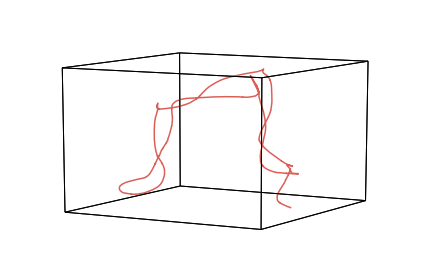

In [18]:
hyp.plot(ep_traj, reduce='UMAP')

/Users/paxtonfitzpatrick/opt/anaconda3/envs/py37/lib/python3.7/site-packages/umap/spectral.py:229: UserWarning: Embedding a total of 2 separate connected components using meta-embedding (experimental)
  n_components


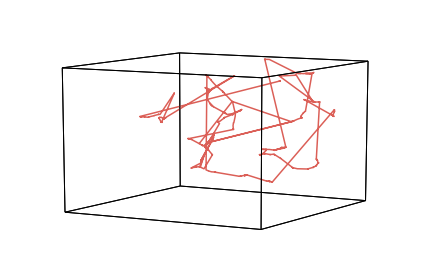

In [19]:
hyp.plot(rec_resampled, reduce='UMAP')

In [26]:
import matplotlib.pyplot as plt

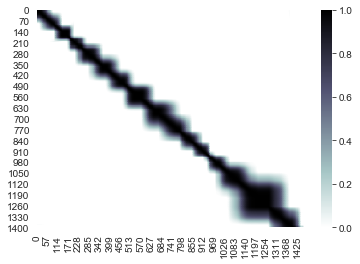

In [28]:
sns.heatmap(pd.DataFrame(ep_traj).T.corr(), cmap=plt.cm.bone_r, vmin=0, vmax=1)

In [15]:
# def fit_and_transform(documents, vec_params=vectorizer_params, sem_params=semantic_params, 
#                         corpus=None, resample_shape=None, return_windows=False):
#     # handle annotations
#     if isinstance(documents, pd.DataFrame):
#         windows = create_windows(documents, data_type='episode')
#         corpus = windows if not corpus else corpus
#         # fit topic model and transform documents
#         traj =  hyp.tools.format_data(windows, vectorizer=vec_params, semantic=sem_params, corpus=corpus)[0]
        
#         # interpolate to length of episode (seconds)
#         if return_windows:
#             return interpolate_episode(traj, documents), windows
#         else:
#             return interpolate_episode(traj, documents)
        
#     # handle recall transcripts
#     elif isinstance(documents, str):
#         if not corpus:
#             raise ValueError("You must pass a training corpus to transform recall transcripts")
#         windows = get_recall_windows(documents, recall_wsize)
#         traj =  hyp.tools.format_data(windows, vectorizer=vec_params, semantic=sem_params, corpus=corpus)[0]
        
#         # resample to corresponding episode length
#         return resample(traj, resample_shape) 

## model episode content, get sliding windows for fitting recall models

In [ ]:
atlep1_traj, atlep1_windows = fit_and_transform(atlep1_df, return_windows=True)
atlep2_traj, atlep2_windows = fit_and_transform(atlep2_df, return_windows=True)
arrdev_traj, arrdev_windows = fit_and_transform(arrdev_df, return_windows=True)

## save episode trajectories

In [ ]:
# np.save(f'{ep_traj_dir}/atlep1_trajectory', atlep1_traj)
# np.save(f'{ep_traj_dir}/atlep2_trajectory', atlep2_traj)
# np.save(f'{ep_traj_dir}/arrdev_trajectory', arrdev_traj)

## load in and model recall transcripts

In [57]:
id_maps

,session 1,session 2
MD-101218-A-01,debugIEH2T:debugDLVLJ,debug2Ea7T:debugosNZ7
MD-101218-B-01,debugBUnNA:debugLtZcs,debugQEynG:debugpwxCU
MD-101218-A-02,debugYQfMB:debugxg7il,debugyBEnU:debugSXeyx
MD-101218-B-02,debugd1YD1:debug4FrAg,debugbu5Bq:debugl91xD
MD-101218-A-03,debug92cgv:debugvdAIT,debugIFCgX:debugt0bgV
MD-101218-B-03,debugGaDml:debugFTHoY,debugBB0yq:debug30NBt
MD-101218-A-04,debugmFRWe:debug4RZkW,debugBhGxH:debugMWNLW
MD-101318-B-01,debug3dOrm:debugAjPUS,debugdHg9G:debugnb698
MD-101318-B-02,debugdhnfF:debug6fW93,debugS5d5Q:debugpxU3l
MD-101318-A-02,debugvnS2Q:debugG20gK,debugNTcAd:debugiaabY


In [61]:
recall_trajectories = {rectype: {} for rectype in ['atlep1', 'delayed', 'atlep2', 'arrdev']}
subids = tqdm(id_maps.index) if show_pbar else id_maps.index
import time

for subid in subids:
    for session in ['session 1', 'session 2']:
        turkid = id_maps.loc[subid, session]
        print(os.listdir(opj(transc_dir, subid, turkid)))

['debugIEH2T:debugDLVLJ-prediction.txt', 'debugIEH2T:debugDLVLJ-recall.txt']
['debug2Ea7T:debugosNZ7-delayed.txt', 'debug2Ea7T:debugosNZ7-recall.txt']
[]
[]
['debugYQfMB:debugxg7il-recall.txt', 'debugYQfMB:debugxg7il-prediction.txt']
['debugyBEnU:debugSXeyx-recall.txt', 'debugyBEnU:debugSXeyx-delayed.txt']
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
['.DS_Store', 'debugFx2Bu:debug5w0Vs-prediction.txt', 'debugFx2Bu:debug5w0Vs-recall.txt']
['debugm7zD9:debugOLIFw-delayed.txt', '.DS_Store', 'debugm7zD9:debugOLIFw-recall.txt']
['.DS_Store', 'debugXxDJj:debugwfW5a-recall.txt', 'debugXxDJj:debugwfW5a-prediction.txt']
['.DS_Store', 'debugprpJQ:debugprHEo-delayed.txt', 'debugprpJQ:debugprHEo-recall.txt']
['debugVmS30:debugTvoFz-recall.txt', 'debugVmS30:debugTvoFz-prediction.txt', '.DS_Store']
['.DS_Store', 'debugOAHPU:debugIjGSz-delayed.txt', 'debugOAHPU:debugIjGSz-recall.txt']
['.DS_Store', 'debugmfo3M:debugCN3V

In [ ]:
recall_trajectories = {
    'atlep1' : [],
    'prediction' : [],
    'delayed' : [],
    'atlep2' : [],
    'arrdev' : []
}

total = sum([len([f for f in files if f.endswith('corrected.wav.txt')]) for r, d, files in os.walk(transc_dir)])
# walk transcription directory structure
currfile = 1
for root, dirs, files in os.walk(transc_dir):
    
    # FOR USE WITH AUTOMATIC TRANSCRIPTS -- REMOVE WHEN SWITCHING TO MANUAL
    transcripts = [f for f in files if f.endswith('corrected.wav.txt')]
    for transc in transcripts:

        # assign correct episode windows, corresponding episode trajectory shape, and dict key
        if any('prediction' in t for t in transcripts) or 'delayed' in transc:
            corpus = atlep1_windows
            resample_shape = atlep1_traj.shape[0]
            if 'recall' in transc:
                rectype = 'atlep1'
            elif 'prediction' in transc:
                rectype = 'prediction'
            elif 'delayed' in transc:
                rectype = 'delayed'
            else:
                raise ValueError('Transcript is not a recognized option')
            
        elif '-A-' in root:
            corpus = atlep2_windows
            resample_shape = atlep2_traj.shape[0]
            rectype = 'atlep2'
            
        else:
            corpus = arrdev_windows
            resample_shape = arrdev_traj.shape[0]
            rectype = 'arrdev'
            
        with open(opj(root ,transc), 'r') as f:
            # FOR USE WITH AUTOMATIC TRANSCRIPTS -- REMOVE WHEN SWITCHING TO MANUAL
            transcript = ' '.join([line.split(',')[0].lower() for line in f.read().split('\n')])
            
        # fit topic model to episode annotations, 
        print(f'modeling transcript {currfile}/{total}...    {transc}')
        p_traj = fit_and_transform(transcript, resample_shape=resample_shape, corpus=corpus)
        
        recall_trajectories[rectype].append((transc.split('-')[0],p_traj))
        currfile += 1

## save individual trajectories

In [ ]:
# for rectype, data in recall_trajectories.items():
#     for (turkid, traj) in data:
#         np.save(opj(rec_traj_dir, rectype, f'{turkid}.npy'), traj)

## create and save average recall trajectories

In [ ]:
# for rectype, data in recall_trajectories.items():
#     avg_trajectory = np.array([traj for (turkid, traj) in data]).mean(axis=0)
#     np.save(opj(rec_traj_dir, rectype, 'avg_trajectory.npy'), avg_trajectory)